In [ ]:
#download using kaggle hub
import kagglehub

path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
print("Dataset downloaded at:", path)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Dataset downloaded at: /kaggle/input/new-plant-diseases-dataset


In [ ]:
#Folder structure
import os

print(os.listdir(path))

['New Plant Diseases Dataset(Augmented)', 'new plant diseases dataset(augmented)', 'test']


In [ ]:
dataset_path = os.path.join(path, "New Plant Diseases Dataset(Augmented)")
print(os.listdir(dataset_path))

['New Plant Diseases Dataset(Augmented)']


In [ ]:
dataset_path = os.path.join(dataset_path, "New Plant Diseases Dataset(Augmented)")
print(os.listdir(dataset_path))

['valid', 'train']


In [ ]:
#train the path
train_path = os.path.join(dataset_path, "train")

classes = os.listdir(train_path)
print("Total classes:", len(classes))
print(classes[:5])

Total classes: 38
['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy']


In [ ]:
#Duplicate removed
from PIL import Image
import imagehash
import os

hashes = {}
duplicates = []

for root, dirs, files in os.walk("custom_dataset"):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path)
            h = imagehash.average_hash(img)

            if h in hashes:
                duplicates.append(path)
            else:
                hashes[h] = path
        except:
            pass

print("Duplicates found:", len(duplicates))

# remove duplicates
for d in duplicates:
    os.remove(d)

print("Duplicates removed")

Duplicates found: 2
Duplicates removed


In [ ]:
#create custom dataset
import shutil
import random

custom_path = "custom_dataset"
selected_classes = classes[:5]

for c in selected_classes:
    os.makedirs(os.path.join(custom_path, c), exist_ok=True)

    images = os.listdir(os.path.join(train_path, c))
    selected = random.sample(images, 200)

    for img in selected:
        shutil.copy(
            os.path.join(train_path, c, img),
            os.path.join(custom_path, c, img)
        )

print("Custom dataset created")

Custom dataset created


In [ ]:
#EDA count
counts = []

for c in selected_classes:
    count = len(os.listdir(os.path.join(custom_path, c)))
    counts.append(count)
    print(c, count)

Tomato___Late_blight 366
Tomato___healthy 375
Grape___healthy 377
Orange___Haunglongbing_(Citrus_greening) 380
Soybean___healthy 383


Tomato___Late_blight 366
Tomato___healthy 375
Grape___healthy 377
Orange___Haunglongbing_(Citrus_greening) 380
Soybean___healthy 383


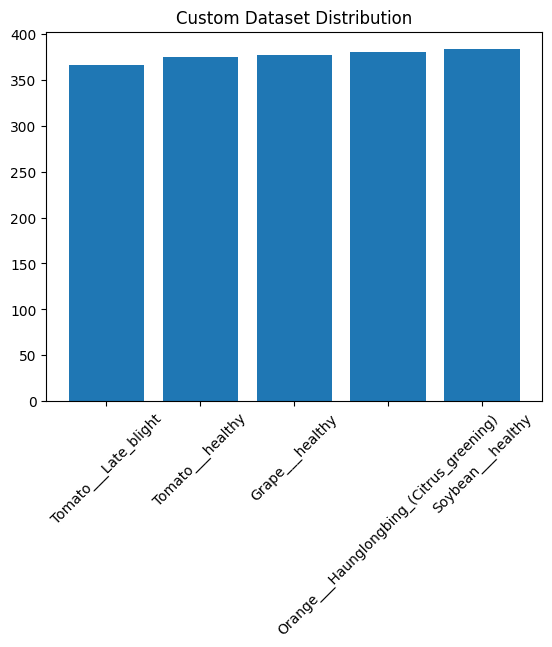

In [ ]:
#EDA bar graph
import matplotlib.pyplot as plt

counts = []

for c in selected_classes:
    count = len(os.listdir(os.path.join(custom_path, c)))
    counts.append(count)
    print(c, count)

plt.bar(selected_classes, counts)
plt.xticks(rotation=45)
plt.title("Custom Dataset Distribution")
plt.show()

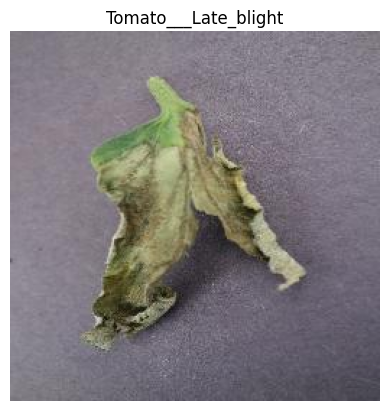

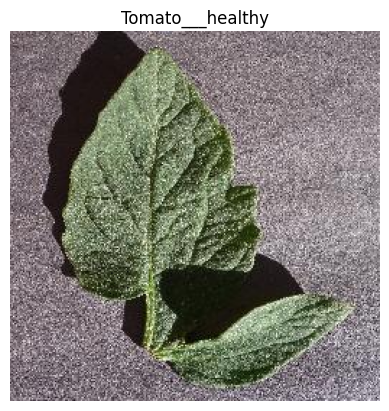

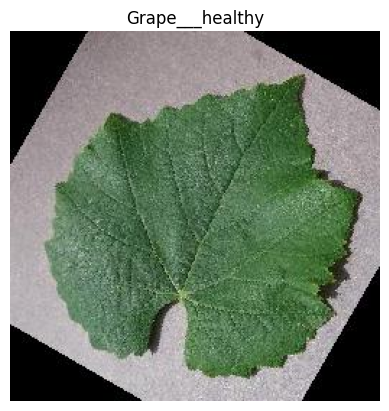

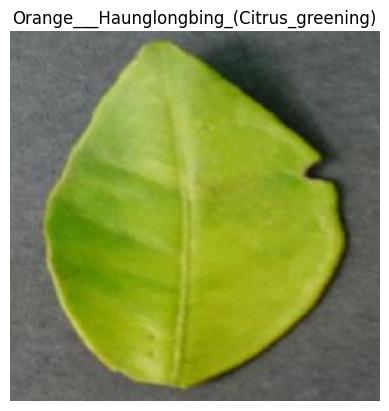

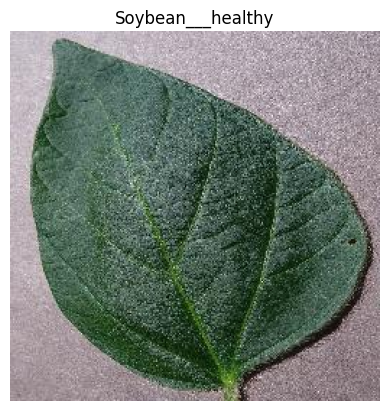

In [ ]:
#visualisation
from PIL import Image

for c in selected_classes:
    img = random.choice(os.listdir(os.path.join(custom_path, c)))
    path_img = os.path.join(custom_path, c, img)

    image = Image.open(path_img)
    plt.imshow(image)
    plt.title(c)
    plt.axis("off")
    plt.show()

In [ ]:
print("Class distribution:", counts)

if len(set(counts)) == 1:
    print("Dataset is balanced")
else:
    print("Dataset is imbalanced")

Class distribution: [366, 375, 377, 380, 383]
Dataset is imbalanced


In [ ]:
sizes = []

for c in selected_classes:
    for img in os.listdir(os.path.join(custom_path, c))[:20]:
        path = os.path.join(custom_path, c, img)
        image = Image.open(path)
        sizes.append(image.size)

print("Sample image sizes:", sizes[:10])

Sample image sizes: [(256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256)]
